# 02 — Piloto de pseudo-rotulagem de urgência com BioBERT

**Projeto:** Medical Triage MLOps  
**Modelo avaliado:** `Yuvrajxms09/biobert-triage-classifier`

## Objetivo

Este notebook **não pseudo-rotula o dataset inteiro de imediato**. Primeiro ele faz um piloto controlado para verificar se o modelo é adequado aos textos do projeto.

O modelo escolhido foi treinado para classificação binária:

- `urgent`
- `non-urgent`

Por isso, neste momento **não criaremos artificialmente a classe `atenção`**. A confiança do modelo não deve ser interpretada como nível de gravidade.

### Fluxo do notebook

```text
Medical Abstracts
      ↓
deduplicação por texto
      ↓
amostra piloto
      ↓
BioBERT Triage Classifier
      ↓
urgent / non-urgent + confiança
      ↓
análise dos resultados
      ↓
decisão sobre a estratégia final
```

> Uso exclusivamente acadêmico. Os pseudo-rótulos não constituem avaliação clínica.

## 1. Dependências

Antes de executar o notebook, instale as bibliotecas no ambiente do projeto:

```bash
uv add transformers torch matplotlib pandas
uv sync
```

Depois selecione o kernel do ambiente `.venv` no VS Code.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from transformers import AutoConfig, AutoTokenizer, pipeline

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

RANDOM_STATE = 42

MODEL_NAME = "Yuvrajxms09/biobert-triage-classifier"
MAX_LENGTH = 256
BATCH_SIZE = 8
PILOT_SIZE = 60

print("Ambiente configurado.")

Ambiente configurado.


## 2. Carregamento do dataset

O piloto utiliza os arquivos originais analisados no EDA.

Como existem textos repetidos entre treino e teste, primeiro unimos os arquivos e mantemos apenas **um registro por texto** para a etapa de pseudo-rotulagem.

In [2]:
def locate_project_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, current.parent, current.parent.parent]:
        expected = candidate / "data" / "raw" / "medical_tc_train.csv"
        if expected.exists():
            return candidate

    raise FileNotFoundError(
        "Não encontrei data/raw/medical_tc_train.csv. "
        "Confira a estrutura do projeto."
    )


PROJECT_ROOT = locate_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(RAW_DATA_DIR / "medical_tc_train.csv")
test = pd.read_csv(RAW_DATA_DIR / "medical_tc_test.csv")
labels = pd.read_csv(RAW_DATA_DIR / "medical_tc_labels.csv")

label_map = dict(zip(labels["condition_label"], labels["condition_name"]))

combined = pd.concat([train, test], ignore_index=True)
combined["medical_abstract"] = (
    combined["medical_abstract"]
    .astype(str)
    .str.strip()
)

unique_texts = (
    combined[["medical_abstract"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"Linhas originais combinadas: {len(combined):,}")
print(f"Textos únicos: {len(unique_texts):,}")

Linhas originais combinadas: 14,438
Textos únicos: 11,227


## 3. Carregamento e inspeção do modelo

Antes de usar o classificador, vamos conferir a configuração fornecida pelo próprio checkpoint.

O model card informa que a saída é binária e que o índice `1` corresponde a `urgent`, enquanto o índice `0` corresponde a `non-urgent`.

In [3]:
config = AutoConfig.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Arquitetura:", config.architectures)
print("Número de labels:", config.num_labels)
print("id2label:", config.id2label)
print("label2id:", config.label2id)

Arquitetura: ['BertForSequenceClassification']
Número de labels: 2
id2label: {0: 'LABEL_0', 1: 'LABEL_1'}
label2id: {'LABEL_0': 0, 'LABEL_1': 1}


In [4]:
if torch.cuda.is_available():
    DEVICE = 0
    device_name = torch.cuda.get_device_name(0)
else:
    DEVICE = -1
    device_name = "CPU"

print(f"Dispositivo selecionado: {device_name}")

classifier = pipeline(
    task="text-classification",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE,
)

Dispositivo selecionado: CPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 4. Teste rápido com exemplos artificiais

Esta etapa serve apenas como **sanity check técnico**. Os exemplos abaixo não medem desempenho clínico do modelo.

In [5]:
sanity_examples = [
    "Patient is asymptomatic and presents for routine follow-up.",
    "Patient reports mild abdominal discomfort for two days and is clinically stable.",
    "Patient has severe chest pain, shortness of breath, and loss of consciousness.",
]

sanity_predictions = classifier(
    sanity_examples,
    truncation=True,
    max_length=MAX_LENGTH,
    top_k=None,
)

for text, prediction in zip(sanity_examples, sanity_predictions):
    print("\nTEXTO:", text)
    print("SAÍDA:", prediction)


TEXTO: Patient is asymptomatic and presents for routine follow-up.
SAÍDA: [{'label': 'LABEL_0', 'score': 0.5810027122497559}, {'label': 'LABEL_1', 'score': 0.41899728775024414}]

TEXTO: Patient reports mild abdominal discomfort for two days and is clinically stable.
SAÍDA: [{'label': 'LABEL_0', 'score': 0.5290296673774719}, {'label': 'LABEL_1', 'score': 0.4709703028202057}]

TEXTO: Patient has severe chest pain, shortness of breath, and loss of consciousness.
SAÍDA: [{'label': 'LABEL_1', 'score': 0.9386532306671143}, {'label': 'LABEL_0', 'score': 0.06134672835469246}]


## 5. Criação da amostra piloto

Utilizamos uma amostra aleatória reproduzível dos textos únicos.  
O objetivo é inspecionar os resultados antes de aplicar o modelo aos milhares de registros.

In [6]:
pilot = unique_texts.sample(
    n=min(PILOT_SIZE, len(unique_texts)),
    random_state=RANDOM_STATE,
).reset_index(drop=True)

display(pilot.head())
print(f"Amostra piloto: {len(pilot)} textos")

,medical_abstract
0,The value of immunohistochemistry for collagen IV expression in colorectal carcinomas. The Dukes' classification has...
1,In vitro drug sensitivity of cells from children with leukemia using the MTT assay with improved culture conditions....
2,"Postarthroscopy analgesia with bupivacaine. A prospective, randomized, blinded evaluation. The analgesic effect of i..."
3,Indirect revascularization of the lower extremity by means of microvascular free-muscle flap--a preliminary report. ...
4,Visceral protothecosis mimicking sclerosing cholangitis in an immunocompetent host: successful antifungal therapy. A...


Amostra piloto: 60 textos


## 6. Comprimento dos textos e possível truncamento

O checkpoint trabalha com limite de sequência. Como os abstracts podem ser longos, verificamos quantos tokens cada texto possui.

Textos acima de `MAX_LENGTH` serão truncados durante a inferência. Isso é uma limitação importante porque informações relevantes podem estar no final do resumo.

In [7]:
def token_count(text: str) -> int:
    return len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )


pilot["n_tokens"] = pilot["medical_abstract"].apply(token_count)
pilot["sera_truncado"] = pilot["n_tokens"] > MAX_LENGTH

display(
    pilot[["n_tokens", "sera_truncado"]]
    .describe(include="all")
)

truncated_pct = pilot["sera_truncado"].mean()

print(
    f"Textos acima de {MAX_LENGTH} tokens: "
    f"{pilot['sera_truncado'].sum()} de {len(pilot)} "
    f"({truncated_pct:.1%})"
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (544 > 512). Running this sequence through the model will result in indexing errors


,n_tokens,sera_truncado
count,60.0000,60
unique,NaN,2
top,NaN,True
freq,NaN,38
mean,313.8000,NaN
std,136.6802,NaN
min,105.0000,NaN
25%,208.7500,NaN
50%,289.5000,NaN
75%,430.2500,NaN


Textos acima de 256 tokens: 38 de 60 (63.3%)


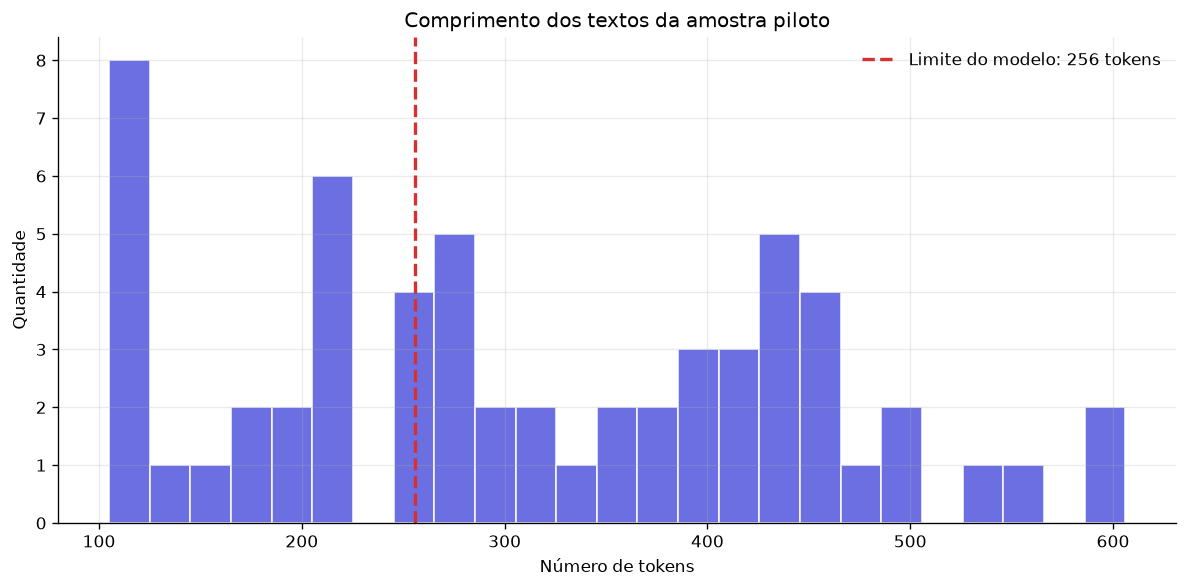

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    pilot["n_tokens"],
    bins=25,
    color="#5B5FDE",
    edgecolor="white",
    alpha=0.9,
)

ax.axvline(
    MAX_LENGTH,
    color="#D63031",
    linestyle="--",
    linewidth=2,
    label=f"Limite do modelo: {MAX_LENGTH} tokens",
)

ax.set_title("Comprimento dos textos da amostra piloto")
ax.set_xlabel("Número de tokens")
ax.set_ylabel("Quantidade")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## 7. Inferência na amostra piloto

In [9]:
raw_predictions = classifier(
    pilot["medical_abstract"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=MAX_LENGTH,
    top_k=None,
)

print(f"Predições geradas: {len(raw_predictions)}")

Predições geradas: 60


### Padronização das saídas

Alguns checkpoints salvam labels como `LABEL_0` e `LABEL_1` em vez de nomes legíveis.

Segundo a documentação do modelo:

- `LABEL_0` → `non-urgent`
- `LABEL_1` → `urgent`

In [10]:
def normalize_label(label: str) -> str:
    normalized = str(label).strip().lower()

    if normalized in {"label_1", "1", "urgent"}:
        return "urgent"

    if normalized in {
        "label_0",
        "0",
        "non-urgent",
        "non_urgent",
        "nonurgent",
    }:
        return "non-urgent"

    return normalized


def parse_prediction(prediction_items):
    normalized_scores = {
        normalize_label(item["label"]): float(item["score"])
        for item in prediction_items
    }

    urgent_score = normalized_scores.get("urgent", np.nan)
    nonurgent_score = normalized_scores.get("non-urgent", np.nan)

    if np.isnan(urgent_score) or np.isnan(nonurgent_score):
        raise ValueError(
            "Não foi possível identificar os scores urgent/non-urgent. "
            f"Saída recebida: {prediction_items}"
        )

    predicted_label = (
        "urgent"
        if urgent_score >= nonurgent_score
        else "non-urgent"
    )

    confidence = max(urgent_score, nonurgent_score)

    return predicted_label, urgent_score, nonurgent_score, confidence


parsed = [
    parse_prediction(prediction)
    for prediction in raw_predictions
]

pilot[
    [
        "triage_prediction",
        "urgent_score",
        "nonurgent_score",
        "confidence",
    ]
] = pd.DataFrame(parsed, index=pilot.index)

display(
    pilot[
        [
            "medical_abstract",
            "triage_prediction",
            "urgent_score",
            "nonurgent_score",
            "confidence",
        ]
    ].head()
)

,medical_abstract,triage_prediction,urgent_score,nonurgent_score,confidence
0,The value of immunohistochemistry for collagen IV expression in colorectal carcinomas. The Dukes' classification has...,non-urgent,0.1950,0.8050,0.8050
1,In vitro drug sensitivity of cells from children with leukemia using the MTT assay with improved culture conditions....,non-urgent,0.3783,0.6217,0.6217
2,"Postarthroscopy analgesia with bupivacaine. A prospective, randomized, blinded evaluation. The analgesic effect of i...",non-urgent,0.1708,0.8292,0.8292
3,Indirect revascularization of the lower extremity by means of microvascular free-muscle flap--a preliminary report. ...,non-urgent,0.4769,0.5231,0.5231
4,Visceral protothecosis mimicking sclerosing cholangitis in an immunocompetent host: successful antifungal therapy. A...,urgent,0.6623,0.3377,0.6623


## 8. Distribuição dos pseudo-rótulos

In [11]:
prediction_distribution = (
    pilot["triage_prediction"]
    .value_counts()
    .rename_axis("classe")
    .reset_index(name="quantidade")
)

prediction_distribution["percentual"] = (
    prediction_distribution["quantidade"] / len(pilot)
)

display(prediction_distribution)

,classe,quantidade,percentual
0,non-urgent,32,0.5333
1,urgent,28,0.4667


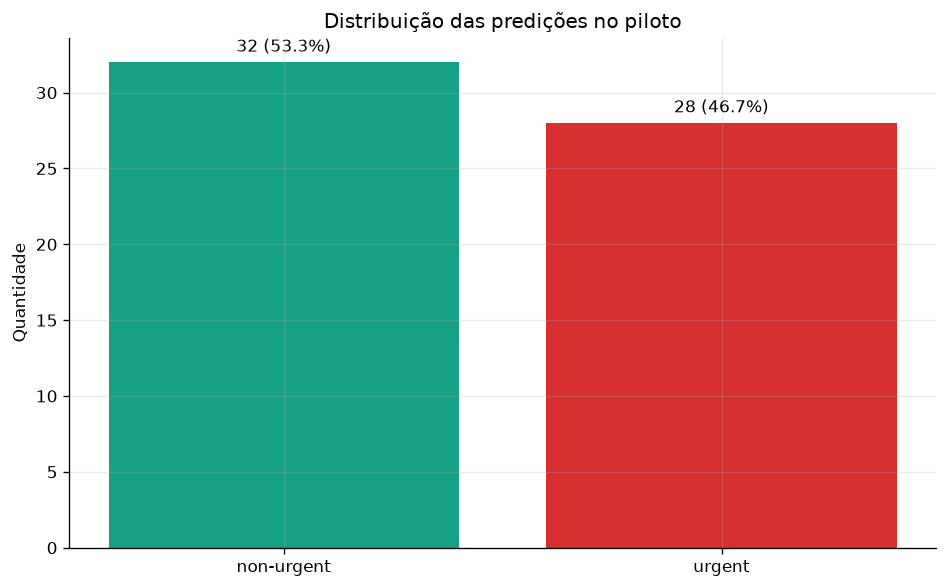

In [12]:
colors = {
    "urgent": "#D63031",
    "non-urgent": "#16A085",
}

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    prediction_distribution["classe"],
    prediction_distribution["quantidade"],
    color=[
        colors.get(label, "#5B5FDE")
        for label in prediction_distribution["classe"]
    ],
)

ax.bar_label(
    bars,
    labels=[
        f"{count} ({pct:.1%})"
        for count, pct in zip(
            prediction_distribution["quantidade"],
            prediction_distribution["percentual"],
        )
    ],
    padding=4,
)

ax.set_title("Distribuição das predições no piloto")
ax.set_ylabel("Quantidade")

plt.tight_layout()
plt.show()

## 9. Análise da confiança

A confiança ajuda a identificar casos que merecem revisão, mas **não representa gravidade**.

Por exemplo, um resultado `urgent = 0.55` não significa "atenção". Significa apenas que o classificador binário está pouco seguro entre `urgent` e `non-urgent`.

In [13]:
display(
    pilot["confidence"]
    .describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
    .to_frame("confidence")
)

,confidence
count,60.0000
mean,0.7057
std,0.1277
min,0.5044
10%,0.5470
25%,0.5872
50%,0.7095
75%,0.8069
90%,0.8650
max,0.9669


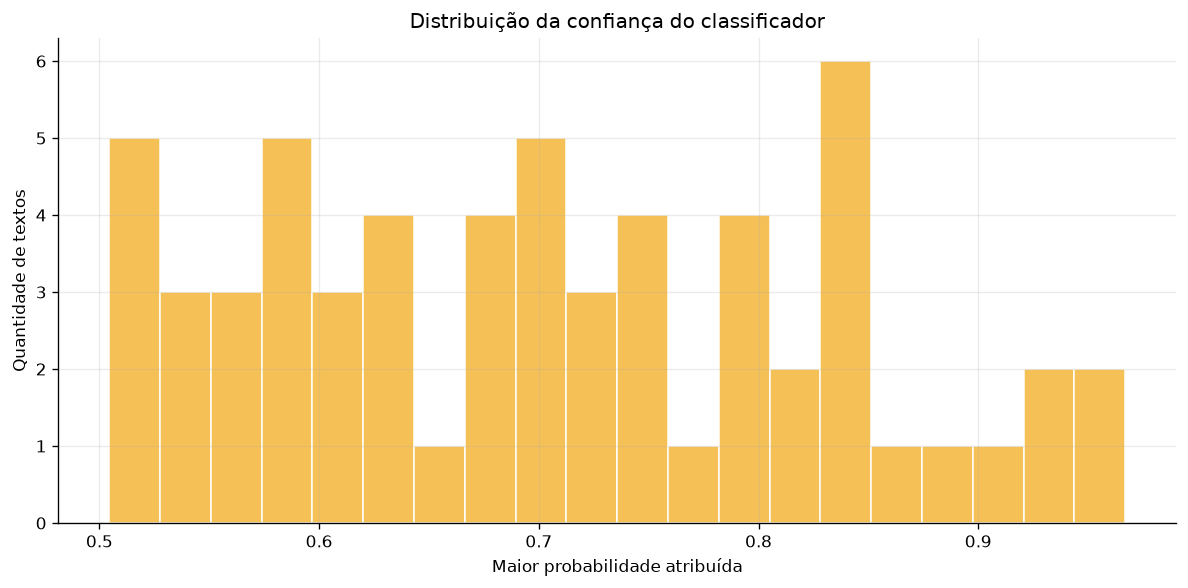

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    pilot["confidence"],
    bins=20,
    color="#F4B942",
    edgecolor="white",
    alpha=0.9,
)

ax.set_title("Distribuição da confiança do classificador")
ax.set_xlabel("Maior probabilidade atribuída")
ax.set_ylabel("Quantidade de textos")

plt.tight_layout()
plt.show()

## 10. Casos mais urgentes segundo o modelo

In [15]:
most_urgent = (
    pilot.sort_values("urgent_score", ascending=False)
    [
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "n_tokens",
            "sera_truncado",
        ]
    ]
    .head(10)
)

display(most_urgent)

,medical_abstract,urgent_score,nonurgent_score,n_tokens,sera_truncado
6,Warning: fatal reaction to the use of fibrin glue in deep hepatic wounds. Case reports. Two cases of severe hypotens...,0.8448,0.1552,107,False
10,"Vascular complications after orthotopic liver transplantation. Over a 57-month period, we performed 430 orthotopic l...",0.8362,0.1638,289,True
22,"Postpartum hemorrhage: placenta accreta, uterine inversion, and puerperal hematomas. Puerperal hematomas, although r...",0.8340,0.1660,110,False
39,Implications of echocardiographically assisted diagnosis of pericardial tamponade in contemporary medical patients: ...,0.7869,0.2131,407,True
41,Brain and spinal cord hemorrhage in long-term survivors of malignant pediatric brain tumors: a possible late effect ...,0.7710,0.2290,139,False
16,Three mixed venous saturation catheters in patients with circulatory shock and respiratory failure Thirty-one critic...,0.7544,0.2456,565,True
29,Brain perfusion in acute encephalitis: relationship to prognosis studied using SPECT. Single photon emission compute...,0.7374,0.2626,166,False
38,Patterns of resource consumption in medical intensive care Intensive care is being scrutinized as a major factor in ...,0.7219,0.2781,196,False
30,Pancreatic involvement in human immunodeficiency virus infection. Involvement of the pancreas by human immunodeficie...,0.7098,0.2902,283,True
43,Differential effect of oncotic pressure on cerebral and extracerebral water content during cardiopulmonary bypass in...,0.7097,0.2903,487,True


## 11. Casos menos urgentes segundo o modelo

In [16]:
least_urgent = (
    pilot.sort_values("urgent_score", ascending=True)
    [
        [
            "medical_abstract",
            "urgent_score",
            "nonurgent_score",
            "n_tokens",
            "sera_truncado",
        ]
    ]
    .head(10)
)

display(least_urgent)

,medical_abstract,urgent_score,nonurgent_score,n_tokens,sera_truncado
46,Stressful events and life satisfaction among elderly men and women. The purpose of this study was to examine the int...,0.0331,0.9669,197,False
48,The relationship of headache symptoms with severity and duration of attacks. Efforts to develop clinically useful he...,0.0461,0.9539,314,True
13,Vitamin E and cancer prevention. Some animal experiments and human studies suggest that vitamin E may protect agains...,0.0569,0.9431,223,False
34,Corporate-sponsored breast cancer screening at the work site: results of a statewide program. Mobile screening mammo...,0.0601,0.9399,209,False
9,Serological evidence of infection with Helicobacter pylori may predict gastrointestinal intolerance to non-steroidal...,0.0840,0.9160,257,True
52,Skeletal manifestations of ectopic or inappropriate endocrine and metabolic syndromes. A variety of tumors and nontu...,0.1121,0.8879,606,True
37,Endoscopic comparison of cimetidine and sucralfate for prevention of naproxen-induced acute gastroduodenal injury. E...,0.1375,0.8625,446,True
47,Studies on autoimmunity for initiation of beta-cell destruction. VI. Macrophages essential for development of beta-c...,0.1559,0.8441,452,True
31,Reconstruction of the chronically insufficient anterior cruciate ligament with the central third of the patellar lig...,0.1656,0.8344,400,True
2,"Postarthroscopy analgesia with bupivacaine. A prospective, randomized, blinded evaluation. The analgesic effect of i...",0.1708,0.8292,225,False


## 12. Casos mais incertos

Esses são os registros mais úteis para inspeção manual, pois o modelo ficou próximo da fronteira entre as duas classes.

In [17]:
most_uncertain = (
    pilot.sort_values("confidence", ascending=True)
    [
        [
            "medical_abstract",
            "triage_prediction",
            "urgent_score",
            "nonurgent_score",
            "confidence",
            "n_tokens",
        ]
    ]
    .head(15)
)

display(most_uncertain)

,medical_abstract,triage_prediction,urgent_score,nonurgent_score,confidence,n_tokens
45,Global and molecular hemostatic markers in acute myeloid leukemia. Patients with acute myeloid leukemia have multipl...,urgent,0.5044,0.4956,0.5044,469
57,Ratio of immunochemically determined amniotic fluid acetylcholinesterase to butyrylcholinesterase in the differentia...,urgent,0.5071,0.4929,0.5071,362
51,Relative risks of left ventricular aneurysmectomy in patients with akinetic scars versus true dyskinetic aneurysms. ...,urgent,0.5196,0.4804,0.5196,431
59,Bleeding from duodenal lymphangiectasia. An 8 year old girl with recurrent upper gastrointestinal bleeding was found...,urgent,0.5223,0.4777,0.5223,105
3,Indirect revascularization of the lower extremity by means of microvascular free-muscle flap--a preliminary report. ...,non-urgent,0.4769,0.5231,0.5231,285
56,Antitumor activity of liposome-encapsulated doxorubicin in advanced breast cancer: phase II study. Previous studies ...,urgent,0.5460,0.4540,0.5460,430
23,Giant cell tumor of bone. A clinicopathologic and DNA flow cytometric analysis. Flow cytometric DNA analysis was per...,non-urgent,0.4529,0.5471,0.5471,433
18,Thromboembolism. A complication of weekly chemotherapy in the treatment of non-Hodgkin's lymphoma. In a retrospectiv...,urgent,0.5499,0.4501,0.5499,123
27,The pharmacology of intravenous and oral etoposide. The epipodophyllotoxin derivative etoposide (VP-16) has been in ...,urgent,0.5629,0.4371,0.5629,601
28,Minute squamous cell carcinoma arising in the wall of a congenital lung cyst. A case of minute squamous cell carcino...,non-urgent,0.4368,0.5632,0.5632,121


## 13. Exportação do piloto

O arquivo abaixo pode ser revisado pelo grupo antes de decidir se o modelo será utilizado para pseudo-rotular todo o dataset.

In [18]:
pilot_output = PROCESSED_DATA_DIR / "triage_pilot_biobert.csv"

pilot.to_csv(pilot_output, index=False)

print(f"Piloto salvo em: {pilot_output}")

Piloto salvo em: C:\Users\necca\OneDrive\Área de Trabalho\Pós-tech\medical-triage-mlops-main\data\processed\triage_pilot_biobert.csv


## 14. Critérios para decidir se seguimos com este modelo

Antes da pseudo-rotulagem completa, recomendamos verificar:

- se os exemplos classificados como `urgent` parecem semanticamente mais graves;
- se os exemplos `non-urgent` parecem coerentes;
- se há excesso de textos truncados;
- se o modelo apresenta forte tendência para uma única classe;
- se os casos incertos fazem sentido;
- se a natureza de **medical questions**, usada no treinamento do modelo, transfere razoavelmente para **medical abstracts**.

### Limitação central

Este checkpoint é **binário**. Ele não produz diretamente:

```text
normal / atenção / urgente
```

Portanto, não devemos criar `atenção` usando apenas um intervalo de confiança.  
**Confiança ≠ severidade.**

Caso o projeto exija três classes, será necessário:

1. usar este modelo apenas como parte de uma estratégia em duas etapas; ou
2. selecionar um modelo/dataset que possua uma escala de triagem com pelo menos três níveis.

## 15. Próximo passo sugerido

Se o piloto for aprovado, o próximo notebook poderá ser:

```text
03_generate_pseudolabels.ipynb
```

Ele aplicará o classificador em todos os textos únicos, salvará os scores e criará um dataset versionado para a etapa de treinamento.

Se o objetivo final permanecer obrigatoriamente em três classes, devemos resolver a definição de `normal / atenção / urgente` **antes** de treinar o MLP.